In [2]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
#import switch
%load_ext autoreload
%autoreload 2

In [66]:
#seed_dirs="../long_sw_100000_fin/"
seed_dirs="../new_ba_100000/"
sw = pd.read_csv('test_files.csv').values
sw

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_1.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_2.csv'],
       ...,
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']],
      shape=(24000, 1), dtype=object)

In [43]:
sw[::10].shape

(2400, 1)

In [44]:
sw[::10][2000].flatten()

array(['p_0.8499999999999996_0.3_0.2_0.0001_0.47000000000000025_seed_0.csv'],
      dtype=object)

In [93]:
for i,file in enumerate(sw[::10][350].flatten()):

    _, beta, sigma,gamma, initi, alpha, _, seed = file.split('\\')[-1].split('_')
    df = pd.read_csv(seed_dirs+file)
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    df['incidence'] = df['incidence'].fillna(0)
    df = df.iloc[:70].fillna(0)
    df.replace([np.inf, -np.inf], 0, inplace=True)

In [94]:
df

,S,E,I,R,Beta,incidence
0,86991,0,10,12999,0.000939,0.0
1,86174,692,124,13010,0.000065,125.0
2,85475,1109,369,13047,0.000027,282.0
3,84615,1557,680,13148,0.000016,412.0
4,83714,1936,1031,13319,0.000013,522.0
...,...,...,...,...,...,...
65,9892,17,107,89984,0.000003,6.0
66,9889,16,89,90006,0.000001,4.0
67,9888,15,78,90019,0.000003,2.0
68,9886,16,66,90032,-0.000000,1.0


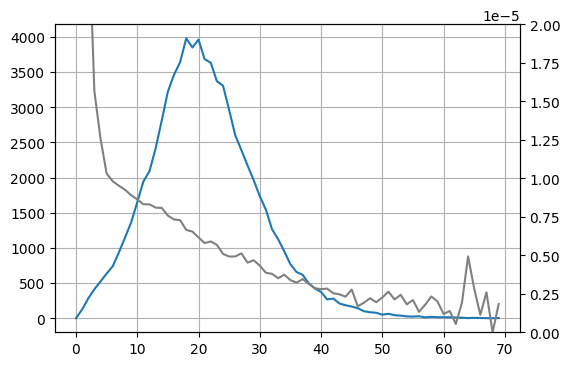

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax_b = ax.twinx()

ax.plot(df.incidence)
ax_b.plot(df.Beta, color='gray')
ax_b.set_ylim(0,2e-5)
#ax.set_xlim(-2,60)
ax.grid()

In [96]:
float(sigma), float(gamma)

(0.3, 0.2)

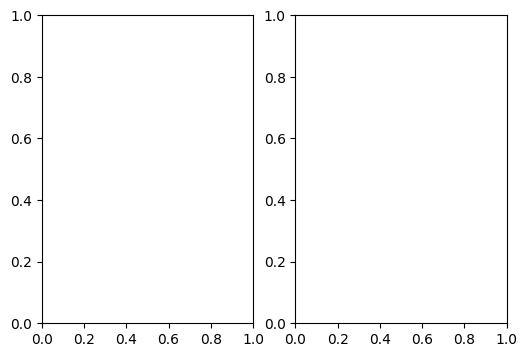

In [132]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

In [134]:
import math

In [171]:
chosen_seeds

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0.csv']],
      dtype=object)

In [177]:
for idx, seed_number in enumerate(chosen_seeds):
    print(idx, seed_number)

0 ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv']
1 ['p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0.csv']


In [213]:
days

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [471]:
chosen_seeds.flatten().shape

(240,)

In [483]:
pd.DataFrame(sw[::10][:2])

,0
0,p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0...
1,p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0...


In [484]:
pd.concat([sww[['beta','alpha']], pd.DataFrame(sw[::10][:2]), df_on_switch], axis=1)

,beta,alpha,0,S,E,I,R,Beta,incidence
0,0.1,0.28,p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0...,27711.0,21.0,79.0,72189.0,9.135887e-07,11.0
1,0.1,0.32,p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0...,31497.0,64.0,125.0,68314.0,1.777947e-06,17.0


In [574]:
chosen_seeds = sw[::10][::1]

days = np.arange(14)
row_n = len(chosen_seeds)//2+math.ceil(len(chosen_seeds)%2)

#fig, ax = plt.subplots(row_n, 2, figsize=(10, row_n*2.5))
#ax = ax.flatten()
ax=days
results = pd.DataFrame([])

for type_start_day, one_ax in zip(days, ax):
    #type_start_day = 1
    beta_prediction_method='real'
    show_fig_flag=False
        
    all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
        all_r2, all_r2_Inc, all_r2_full, all_r2_Inc_full,\
        all_peak, execution_time, start_days,df_on_switch = \
            plot_hyb.main_f('seir', count_stoch_line=0, 
                           beta_prediction_method=beta_prediction_method, 
                           type_start_day=type_start_day, seed_numbers=chosen_seeds,
                           show_fig_flag=show_fig_flag, seed_dirs=seed_dirs, 
                           sigma=0.3, gamma=0.2,
                           ax = None, model_path='', perc_switch=0.01,
                           is_filename=True, on_incidence=True,
                           switch_on_incidence=False, detailed=True)
    
    sww = pd.Series(chosen_seeds.flatten()).str.split('_',expand=True)
    sww.columns = ['p','beta','sigma','gamma','initi',
               'alpha','seed','nseed']
    sww[['beta','alpha']] = sww[['beta','alpha']].astype(float).round(2)

    # creating a dataframe for peaks
    all_peak = pd.DataFrame(all_peak, 
                    columns=['actual_peak_I', 'predicted_peak_I', 
                            'actual_peak_Inc', 'predicted_peak_inc',
                            'actual_peak_day', 'predicted_peak_day',
                            'actual_peak_day_Inc', 'predicted_peak_day_inc'])
    # creating a dataframe for peaks RMSE, predicted time, start day
    rmse_df = pd.DataFrame({
        'type_start_day': start_days,
        'rmse_I': all_rmse_I,
        'rmse_Inc': all_rmse_Inc,
        'rmse_Beta': all_rmse_Beta,
        'r2': all_r2,
        'r2_Inc': all_r2_Inc,
        'r2_full': all_r2_full,
        'r2_Inc_full': all_r2_Inc_full,
        'time_predict': execution_time,
    })
    df_on_switch = pd.DataFrame(df_on_switch, 
                                columns = ['S','E','I','R','Beta','incidence'])
    seeds_info = pd.concat([sww[['beta','alpha']], 
                            pd.DataFrame(chosen_seeds, columns=['file']), 
                            df_on_switch], axis=1)
    # merging dataframes
    full_one = pd.concat([seeds_info, rmse_df, all_peak], axis=1)
    results = pd.concat([results, full_one], axis=0)

In [575]:
results

,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,r2_Inc_full,time_predict,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc
0,0.10,0.28,p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0...,27990.0,0.0,10.0,72000.0,0.000289,0.0,0,...,0.931624,0.004001,105,96.0,38.0,31.0,9,6,6,4
1,0.10,0.32,p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0...,31990.0,0.0,10.0,68000.0,0.000341,0.0,0,...,0.905413,0.004000,171,147.0,55.0,43.0,10,8,8,5
2,0.10,0.34,p_0.1_0.3_0.2_0.0001_0.34000000000000014_seed_...,33991.0,0.0,10.0,65999.0,0.000321,0.0,0,...,0.888667,0.004000,187,151.0,64.0,41.0,9,9,6,5
3,0.10,0.35,p_0.1_0.3_0.2_0.0001_0.35000000000000014_seed_...,34991.0,0.0,10.0,64999.0,0.000271,0.0,0,...,0.831492,0.004000,186,129.0,56.0,34.0,11,10,5,5
4,0.10,0.37,p_0.1_0.3_0.2_0.0001_0.37000000000000016_seed_...,36991.0,0.0,10.0,62999.0,0.000308,0.0,0,...,0.859414,0.005997,162,127.0,57.0,36.0,7,8,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,0.99,0.80,p_0.9899999999999995_0.3_0.2_0.0001_0.80000000...,14719.0,18715.0,23026.0,43540.0,0.000009,5822.0,13,...,0.998709,0.003000,23486,24049.0,6326.0,5822.0,15,15,13,13
2396,0.99,0.82,p_0.9899999999999995_0.3_0.2_0.0001_0.82000000...,10034.0,17520.0,25459.0,46987.0,0.000008,5551.0,13,...,0.998603,0.003511,25459,25623.0,6851.0,5551.0,14,14,11,13
2397,0.99,0.91,p_0.9899999999999995_0.3_0.2_0.0001_0.91000000...,2341.0,12860.0,30312.0,54487.0,0.000007,4379.0,13,...,0.999493,0.004000,32903,30312.0,9930.0,4379.0,12,13,9,13
2398,0.99,0.94,p_0.9899999999999995_0.3_0.2_0.0001_0.94000000...,1051.0,10591.0,29624.0,58734.0,0.000006,3586.0,13,...,0.999669,0.004000,35349,29624.0,11358.0,3586.0,11,13,8,13


In [576]:
filtered = results[results.type_start_day<results.actual_peak_day]
filtered[['S','E','I','R','incidence']
        ] = (filtered[['S','E','I','R','incidence']]/100000).round(2)

filtered['days_until_peak_I'] = filtered.actual_peak_day - filtered.type_start_day
filtered['ab'] = (filtered.beta*filtered.alpha).round(3)
filtered

,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
0,0.10,0.28,p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0...,0.28,0.00,0.00,0.72,0.000289,0.00,0,...,105,96.0,38.0,31.0,9,6,6,4,9,0.028
1,0.10,0.32,p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0...,0.32,0.00,0.00,0.68,0.000341,0.00,0,...,171,147.0,55.0,43.0,10,8,8,5,10,0.032
2,0.10,0.34,p_0.1_0.3_0.2_0.0001_0.34000000000000014_seed_...,0.34,0.00,0.00,0.66,0.000321,0.00,0,...,187,151.0,64.0,41.0,9,9,6,5,9,0.034
3,0.10,0.35,p_0.1_0.3_0.2_0.0001_0.35000000000000014_seed_...,0.35,0.00,0.00,0.65,0.000271,0.00,0,...,186,129.0,56.0,34.0,11,10,5,5,11,0.035
4,0.10,0.37,p_0.1_0.3_0.2_0.0001_0.37000000000000016_seed_...,0.37,0.00,0.00,0.63,0.000308,0.00,0,...,162,127.0,57.0,36.0,7,8,7,5,7,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,0.99,0.70,p_0.9899999999999995_0.3_0.2_0.0001_0.70000000...,0.30,0.13,0.13,0.44,0.000009,0.04,13,...,15776,16518.0,4063.0,3978.0,18,17,15,14,5,0.693
2393,0.99,0.75,p_0.9899999999999995_0.3_0.2_0.0001_0.75000000...,0.20,0.16,0.19,0.45,0.000009,0.05,13,...,20244,20562.0,5131.0,5066.0,16,15,13,13,3,0.742
2394,0.99,0.79,p_0.9899999999999995_0.3_0.2_0.0001_0.79000000...,0.14,0.17,0.23,0.46,0.000008,0.05,13,...,22838,23329.0,6142.0,5447.0,15,14,12,13,2,0.782
2395,0.99,0.80,p_0.9899999999999995_0.3_0.2_0.0001_0.80000000...,0.15,0.19,0.23,0.44,0.000009,0.06,13,...,23486,24049.0,6326.0,5822.0,15,15,13,13,2,0.792


In [497]:
filtered.columns

Index(['beta', 'alpha', 'file', 'S', 'E', 'I', 'R', 'Beta', 'incidence',
       'type_start_day', 'rmse_I', 'rmse_Inc', 'rmse_Beta', 'r2', 'r2_Inc',
       'r2_full', 'r2_Inc_full', 'time_predict', 'actual_peak_I',
       'predicted_peak_I', 'actual_peak_Inc', 'predicted_peak_inc',
       'actual_peak_day', 'predicted_peak_day', 'actual_peak_day_Inc',
       'predicted_peak_day_inc', 'days_until_peak_I', 'ab'],
      dtype='object')

<Axes: xlabel='type_start_day', ylabel='rmse_Inc'>

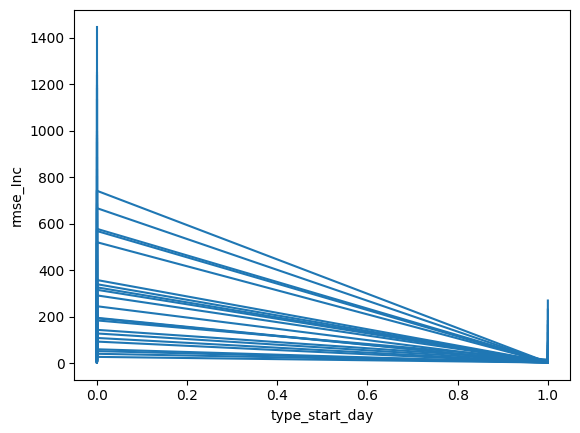

In [316]:
sns.lineplot(data = filtered.iloc[:300],
               x='type_start_day', y='rmse_Inc',
             units="beta",estimator=None
            )

<Axes: xlabel='type_start_day', ylabel='rmse_Inc'>

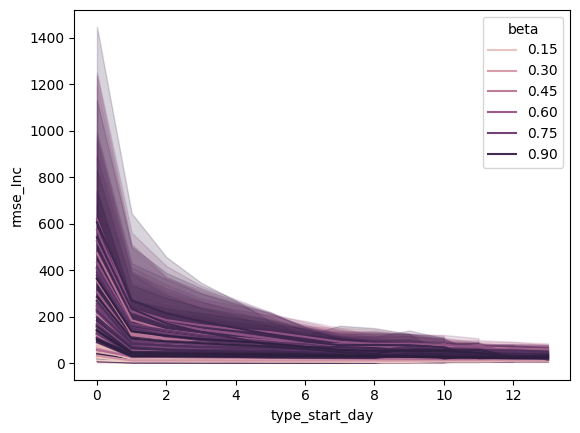

In [342]:
sns.lineplot(data = filtered,
               x='type_start_day', y='rmse_Inc', hue='beta')

In [287]:
filtered.pivot(columns=['beta','alpha'], index='type_start_day', 
                             values='rmse_Inc')

beta                0.10                            0.11                       \
alpha               0.28       0.51       0.79      0.27      0.42       0.72   
type_start_day                                                                  
0               1.946792  13.852076  59.933630  4.673329  4.477723  27.216355   
1               1.845004   5.264710  24.301141  2.933609  4.500281  12.791648   
2               1.528638   5.290538  27.049275  2.950268  3.793119  13.425152   
3               1.481849   4.802276  28.172334  2.871833  3.571075  11.951362   
4               1.428869   4.687083  26.440381  2.904738  3.569255  12.331785   
5               1.372665   4.702743  26.205664  2.741494  3.582119  11.016256   
6               1.250532   4.556968  25.071600  2.822780  3.598167  10.609610   
7               1.195871   4.231220  26.205761  2.497310  3.445427  10.591130   
8               1.229174   4.321332  24.511754  1.753878  2.839933  10.318304   
9                    NaN   4.331079  25.460808  1.683795  2.631174  10.261954   
10                   NaN   4.298579  24.788886       NaN  2.575526  10.789913   
11                   NaN   4.251900  24.298472       NaN  2.568172  10.677604   
12                   NaN        NaN  24.410784       NaN       NaN  10.481043   
13                   NaN        NaN  24.382253       NaN       NaN  10.627442   

beta                0.12                            0.13  ...       0.96  \
alpha               0.29      0.48        0.88      0.32  ...       0.26   
type_start_day                                            ...              
0               3.937004  7.513322  195.399872  3.991240  ...  12.771061   
1               2.245084  3.854684   48.526261  2.278578  ...   4.427873   
2               2.070197  3.528311   54.598815  2.401105  ...   4.335426   
3               1.877704  3.369053   54.530328  1.997421  ...   4.081641   
4               1.870829  3.336977   52.302904  1.963203  ...   4.040163   
5               1.935812  2.925388   50.404991  1.968168  ...   3.287936   
6               1.847943  2.858358   48.389268  1.910219  ...   2.432055   
7               1.854956  2.883024   46.550701  1.934408  ...   2.456066   
8                    NaN  2.909878   48.859937  1.856247  ...   2.391107   
9                    NaN  2.903200   49.206003  1.907187  ...        NaN   
10                   NaN  2.786874   48.314134       NaN  ...        NaN   
11                   NaN       NaN   45.639156       NaN  ...        NaN   
12                   NaN       NaN   44.244286       NaN  ...        NaN   
13                   NaN       NaN   43.810197       NaN  ...        NaN   

beta                                        0.97                          \
alpha                0.57        0.88       0.38        0.67        0.90   
type_start_day                                                             
0               98.120283  742.484498  30.183605  227.703447  831.709216   
1               40.225250  270.875069   9.630549   63.948764  335.671361   
2               39.906651  235.955461   8.711943   62.675794  280.962595   
3               37.900439  214.861140   8.163282   62.331918  239.401229   
4               35.541789  193.297051   8.089345   61.045833  212.137829   
5               33.603884  174.657047   7.586692   59.182590  185.301035   
6               32.356064  148.670419   7.570941   58.546944  144.482127   
7               31.090053  108.253834   7.603763   56.494076  105.787625   
8               30.557145   87.622089   7.583592   54.012579   98.069075   
9               29.470417   88.838599   7.449463   50.723664  100.666078   
10              27.995436   87.856891   7.327270   47.568897   98.379311   
11              27.786505   85.869773   7.441155   39.265160   88.946897   
12              26.438393         NaN   7.461264   36.714036         NaN   
13              26.049467         NaN        NaN   33.506390         NaN   

beta                 0.98           

In [266]:
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, MultipleLocator

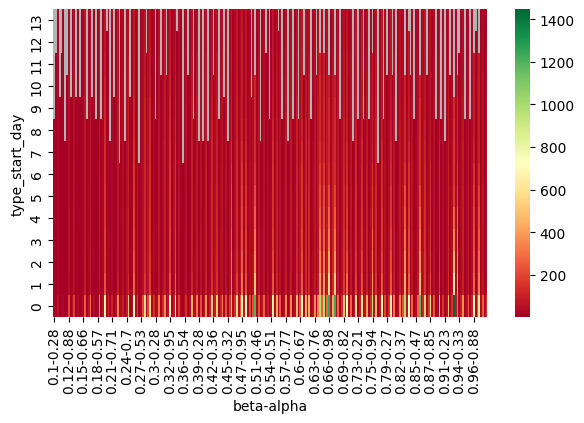

In [289]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot(columns=['beta','alpha'], index='type_start_day', 
                             values='rmse_Inc')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [498]:
filtered[['alpha','beta']].drop_duplicates()

,alpha,beta
0,0.28,0.10
1,0.51,0.10
2,0.79,0.10
3,0.27,0.11
4,0.42,0.11
...,...,...
235,0.90,0.97
236,0.40,0.98
237,0.68,0.98
238,0.39,0.99


In [499]:
gg = filtered.groupby(['beta','alpha'])
groupes = gg.groups.keys()
len(list(groupes))

240

<Axes: >

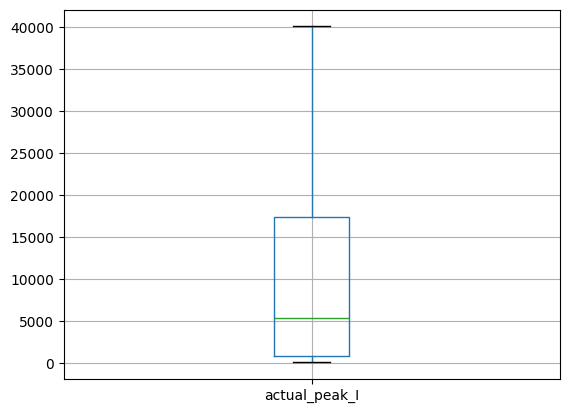

In [500]:
filtered[['actual_peak_I']].boxplot()

In [501]:
gg2 = filtered[filtered.actual_peak_I>=5000].groupby(['beta','alpha'])
groupes2 = gg2.groups.keys()
len(list(groupes2))

113

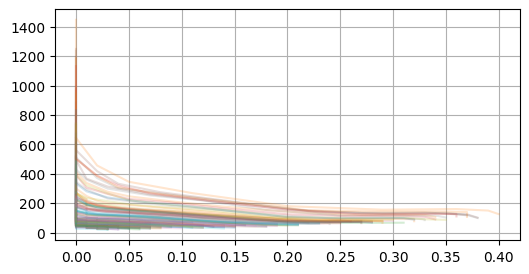

In [502]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

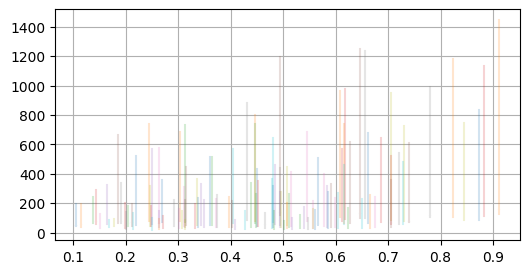

In [503]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.beta*one_group.alpha, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

In [504]:
filtered.shape, filtered['ab'].nunique()

((3031, 28), 201)

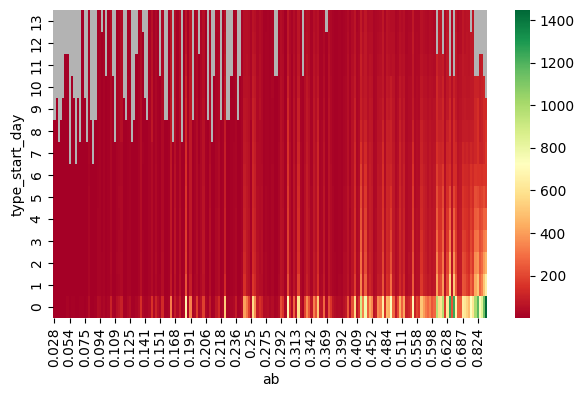

In [505]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='type_start_day', 
                             values='rmse_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [506]:
list(groupes2)[::20]

[(0.12, 0.88),
 (0.31, 0.87),
 (0.47, 0.72),
 (0.64, 0.75),
 (0.77, 0.86),
 (0.92, 0.61)]

In [507]:
gg2.get_group(list(groupes2)[0])

,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.88,0.00,0.00,0.12,0.000486,0.00,0,...,9470,8964.0,2065.0,1906.0,36,37,31,34,36,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.88,0.00,0.00,0.12,0.000071,0.00,1,...,9470,10008.0,2065.0,2123.0,36,34,31,31,35,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.87,0.01,0.00,0.12,0.000022,0.00,2,...,9470,10072.0,2065.0,2134.0,36,33,31,31,34,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.87,0.01,0.00,0.12,0.000013,0.00,3,...,9470,10066.0,2065.0,2133.0,36,33,31,31,33,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.86,0.01,0.01,0.12,0.000010,0.00,4,...,9470,10041.0,2065.0,2128.0,36,34,31,31,32,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.86,0.01,0.01,0.12,0.000008,0.00,5,...,9470,10019.0,2065.0,2124.0,36,34,31,31,31,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.85,0.01,0.01,0.12,0.000008,0.00,6,...,9470,9991.0,2065.0,2119.0,36,34,31,31,30,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.85,0.01,0.01,0.13,0.000007,0.00,7,...,9470,9959.0,2065.0,2113.0,36,34,31,31,29,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.84,0.02,0.01,0.13,0.000006,0.00,8,...,9470,9990.0,2065.0,2118.0,36,34,31,31,28,0.106
8,0.12,0.88,p_0.12_0.3_0.2_0.0001_0.8800000000000006_seed_...,0.83,0.02,0.02,0.13,0.000006,0.01,9,...,9470,9991.0,2065.0,2118.0,36,34,31,31,27,0.106


In [508]:
gg2.get_group(list(groupes2)[-1])

,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.63,0.00,0.00,0.37,0.002567,0.00,0,...,10948,10508.0,2597.0,2387.0,21,21,18,18,21,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.61,0.01,0.00,0.37,0.000072,0.00,1,...,10948,11728.0,2597.0,2667.0,21,20,18,17,20,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.60,0.02,0.01,0.37,0.000024,0.00,2,...,10948,11724.0,2597.0,2666.0,21,20,18,17,19,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.60,0.02,0.01,0.37,0.000016,0.01,3,...,10948,11688.0,2597.0,2658.0,21,20,18,17,18,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.59,0.02,0.02,0.38,0.000015,0.01,4,...,10948,11628.0,2597.0,2644.0,21,20,18,17,17,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.57,0.03,0.02,0.38,0.000013,0.01,5,...,10948,11601.0,2597.0,2637.0,21,20,18,17,16,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.56,0.03,0.02,0.38,0.000013,0.01,6,...,10948,11584.0,2597.0,2633.0,21,20,18,17,15,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.54,0.04,0.03,0.39,0.000012,0.01,7,...,10948,11557.0,2597.0,2626.0,21,20,18,17,14,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.52,0.05,0.04,0.39,0.000011,0.01,8,...,10948,11568.0,2597.0,2629.0,21,20,18,17,13,0.624
239,0.99,0.63,p_0.9899999999999995_0.3_0.2_0.0001_0.63000000...,0.50,0.05,0.04,0.40,0.000011,0.02,9,...,10948,11523.0,2597.0,2618.0,21,20,18,17,12,0.624


In [513]:
gg2.get_group(group_label)['file'].values[0]

'p_0.9899999999999995_0.3_0.2_0.0001_0.6300000000000003_seed_0.csv'

In [526]:
sigma, gamma

('0.3', '0.2')

In [ ]:
 all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
        all_r2, all_r2_Inc, all_r2_full, all_r2_Inc_full,\
        all_peak, execution_time, start_days,df_on_switch = \
            plot_hyb.main_f('seir', count_stoch_line=0, 
                           beta_prediction_method=beta_prediction_method, 
                           type_start_day=type_start_day, seed_numbers=chosen_seeds,
                           show_fig_flag=show_fig_flag, seed_dirs=seed_dirs, 
                           sigma=0.3, gamma=0.2,
                           ax = None, model_path='', perc_switch=0.01,
                           is_filename=True, on_incidence=True,
                           switch_on_incidence=False, detailed=True)

In [568]:
group_label = list(groupes2)[::20][4]
beta, alpha = group_label

gg2.get_group(group_label)


,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.86,0.00,0.00,0.14,0.002853,0.00,0,...,27727,26463.0,7805.0,6861.0,14,15,11,12,14,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.84,0.02,0.00,0.14,0.000093,0.00,1,...,27727,29166.0,7805.0,7839.0,14,13,11,11,13,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.81,0.04,0.01,0.14,0.000039,0.01,2,...,27727,29480.0,7805.0,7904.0,14,13,11,11,12,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.78,0.06,0.02,0.14,0.000028,0.01,3,...,27727,29578.0,7805.0,7959.0,14,13,11,10,11,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.73,0.09,0.04,0.15,0.000025,0.02,4,...,27727,29622.0,7805.0,7992.0,14,13,11,10,10,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.66,0.12,0.06,0.16,0.000022,0.03,5,...,27727,29587.0,7805.0,7998.0,14,13,11,10,9,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.57,0.17,0.09,0.17,0.000020,0.04,6,...,27727,29461.0,7805.0,7967.0,14,13,11,10,8,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.47,0.21,0.12,0.19,0.000017,0.06,7,...,27727,29316.0,7805.0,7923.0,14,13,11,10,7,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.37,0.24,0.16,0.22,0.000015,0.07,8,...,27727,29080.0,7805.0,7832.0,14,13,11,10,6,0.662
181,0.77,0.86,p_0.7699999999999997_0.3_0.2_0.0001_0.86000000...,0.28,0.26,0.20,0.26,0.000013,0.08,9,...,27727,28832.0,7805.0,7722.0,14,13,11,10,5,0.662


Видимо, тк (2й сид) и за 2-3 недели хорошо прогноизируем, то раз у 1-го сида пик ближе, то тем более хороший результат.

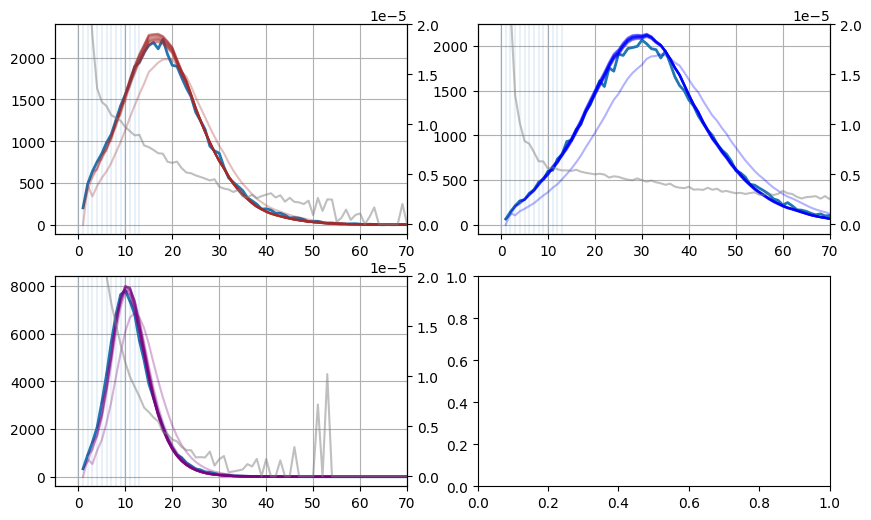

In [572]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6), squeeze=False)
ax = ax.flatten()

#brown

for ax0, color, group_id in zip(ax, ['brown','blue','purple'], [-1,0,4]):
    group_label = list(groupes2)[::20][group_id]
    beta, alpha = group_label

    filen = gg2.get_group(group_label)['file'].values[0]
    seed_df = pd.read_csv(seed_dirs+filen)

    temp = seed_df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    ax0.plot(seed_df.incidence, lw=2)
    ax_b = ax0.twinx()
    ax_b.plot(seed_df.Beta, color='gray', alpha=.5)
    
    for i in range(14):
        start_days=[]
        start_day = i
        start_days.append(start_day)
        predicted_days = np.arange(start_day, seed_df.shape[0])
        # choosing the days for prediction
        predicted_days = np.arange(start_day, seed_df.shape[0])

        beggining_beta, predicted_beta, \
                predicted_I = predict_Beta_I.predict_beta(
                                'seir', seed_df,
                                'real', 
                                predicted_days, False, 
                                0, float(sigma), float(gamma),
                                '', '', 4)
        


        predicted_Inc = np.zeros((0+1, 
                                      predicted_days.shape[0]))
        y = seed_df.iloc[predicted_days[0],:4]
        # predict the Infected compartment trajectory
        ss,ee,predicted_I[0],\
            _ = predict_Beta_I.predict_I('seir', y,
                                          predicted_days-start_day,
                                          predicted_beta,
                                          float(sigma), float(gamma), 'det')
        # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
        from_last = seed_df['incidence'].iloc[predicted_days[0]]
        predicted_Inc[0] = np.append(from_last, 
                                   (ee[:-1] - ee[1:]) - \
                                       (ss[1:] - ss[:-1]))
        predicted_Inc[0][predicted_Inc[0]<0] = 0
        
        ax0.plot(predicted_days,predicted_Inc[0], color=color,alpha=.3) 
        ax0.axvline(i, alpha=.1)
        ax0.set_xlim(-5,70)
        
    ax_b.set_ylim(-1e-6,2e-5)
    ax0.grid()


In [459]:
list(groupes2)[-1]

(0.99, 0.63)

In [463]:
q,w = group_label
q+1,w

(1.99, 0.63)

(-10.0, 800.0)

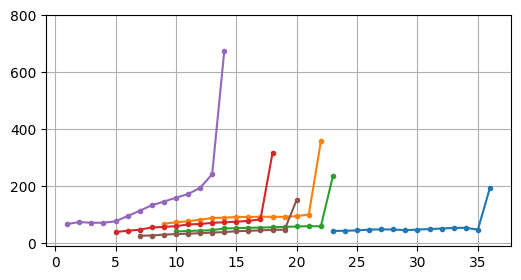

In [573]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::20]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='.', ls='-', alpha=1)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

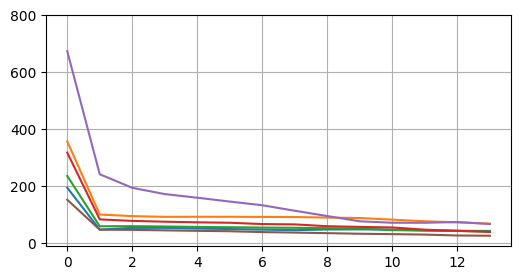

In [555]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::20]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()
plt.ylim(-10,800)

Здесь видно, что у одного сида ошибка 15 дней до пика == у другого сида ошибка 5 дней до пика

т.е. разница в ... ??

(-10.0, 800.0)

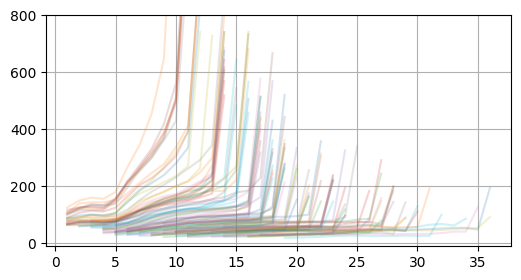

In [450]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
plt.ylim(-10,800)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

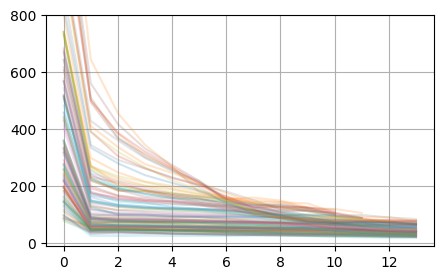

In [423]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

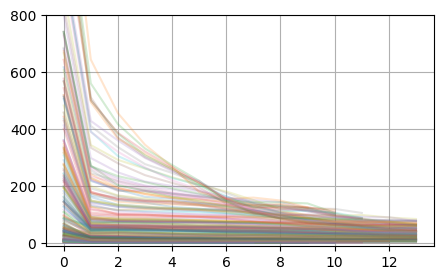

In [414]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
for group in list(groupes):
    one_group = gg.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

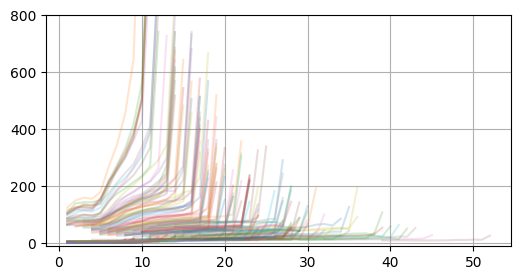

In [408]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes):
    one_group = gg.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
plt.ylim(-10,800)

In [404]:
one_group.columns

Index(['beta', 'alpha', 'S', 'E', 'I', 'R', 'Beta', 'incidence',
       'type_start_day', 'rmse_I', 'rmse_Inc', 'rmse_Beta', 'r2', 'r2_Inc',
       'r2_full', 'r2_Inc_full', 'time_predict', 'actual_peak_I',
       'predicted_peak_I', 'actual_peak_Inc', 'predicted_peak_inc',
       'actual_peak_day', 'predicted_peak_day', 'actual_peak_day_Inc',
       'predicted_peak_day_inc', 'days_until_peak_I'],
      dtype='object')

In [ ]:
for i in gg.groups

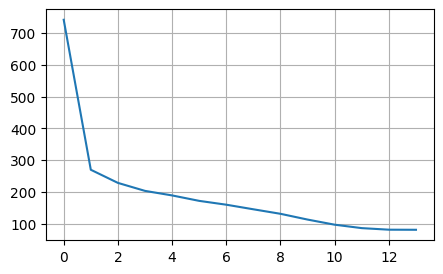

In [368]:
plt.subplots(1,1, figsize=(5,3))

chosen = filtered[(filtered.alpha==0.98)&(filtered.beta==0.25)]
plt.plot(chosen.type_start_day, chosen.rmse_Inc, 
         marker='', ls='-')
plt.grid()

In [102]:
start_day = 5
predicted_days = np.arange(start_day, df.shape[0])

beggining_beta, predicted_beta, \
            predicted_I = predict_Beta_I.predict_beta(
                            I_prediction_method='seir', seed_df=df,
                            beta_prediction_method='last value', 
                            predicted_days=predicted_days, stochastic=False, 
                            count_stoch_line=0, sigma=float(sigma), gamma=float(gamma),
                            window_size=4)
count_stoch_line=0
predicted_Inc = np.zeros((count_stoch_line+1, 
                                  predicted_days.shape[0]))

# use predicted Beta values for predicting I
# extract compartment values on the switch day
y = seed_df.iloc[predicted_days[0],:4]
# predict the Infected compartment trajectory

ss,ee,predicted_I[0],\
    _ = predict_Beta_I.predict_I(I_prediction_method, y,
                                  predicted_days-start_day,
                                  predicted_beta,
                                  sigma, gamma, 'det')
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
if on_incidence:
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    from_last = seed_df['incidence'].iloc[predicted_days[0]]
    predicted_Inc[0] = np.append(from_last, 
                               (ee[:-1] - ee[1:]) - \
                                   (ss[1:] - ss[:-1]))
    predicted_Inc[0][predicted_Inc[0]<0] = 0

In [103]:
predicted_Inc

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.]])

In [99]:
beggining_beta, predicted_beta

(array([], dtype=float64),
 array([1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-05, 1.03089856e-05, 1.03089856e-05,
        1.03089856e-05, 1.03089856e-0

0.01


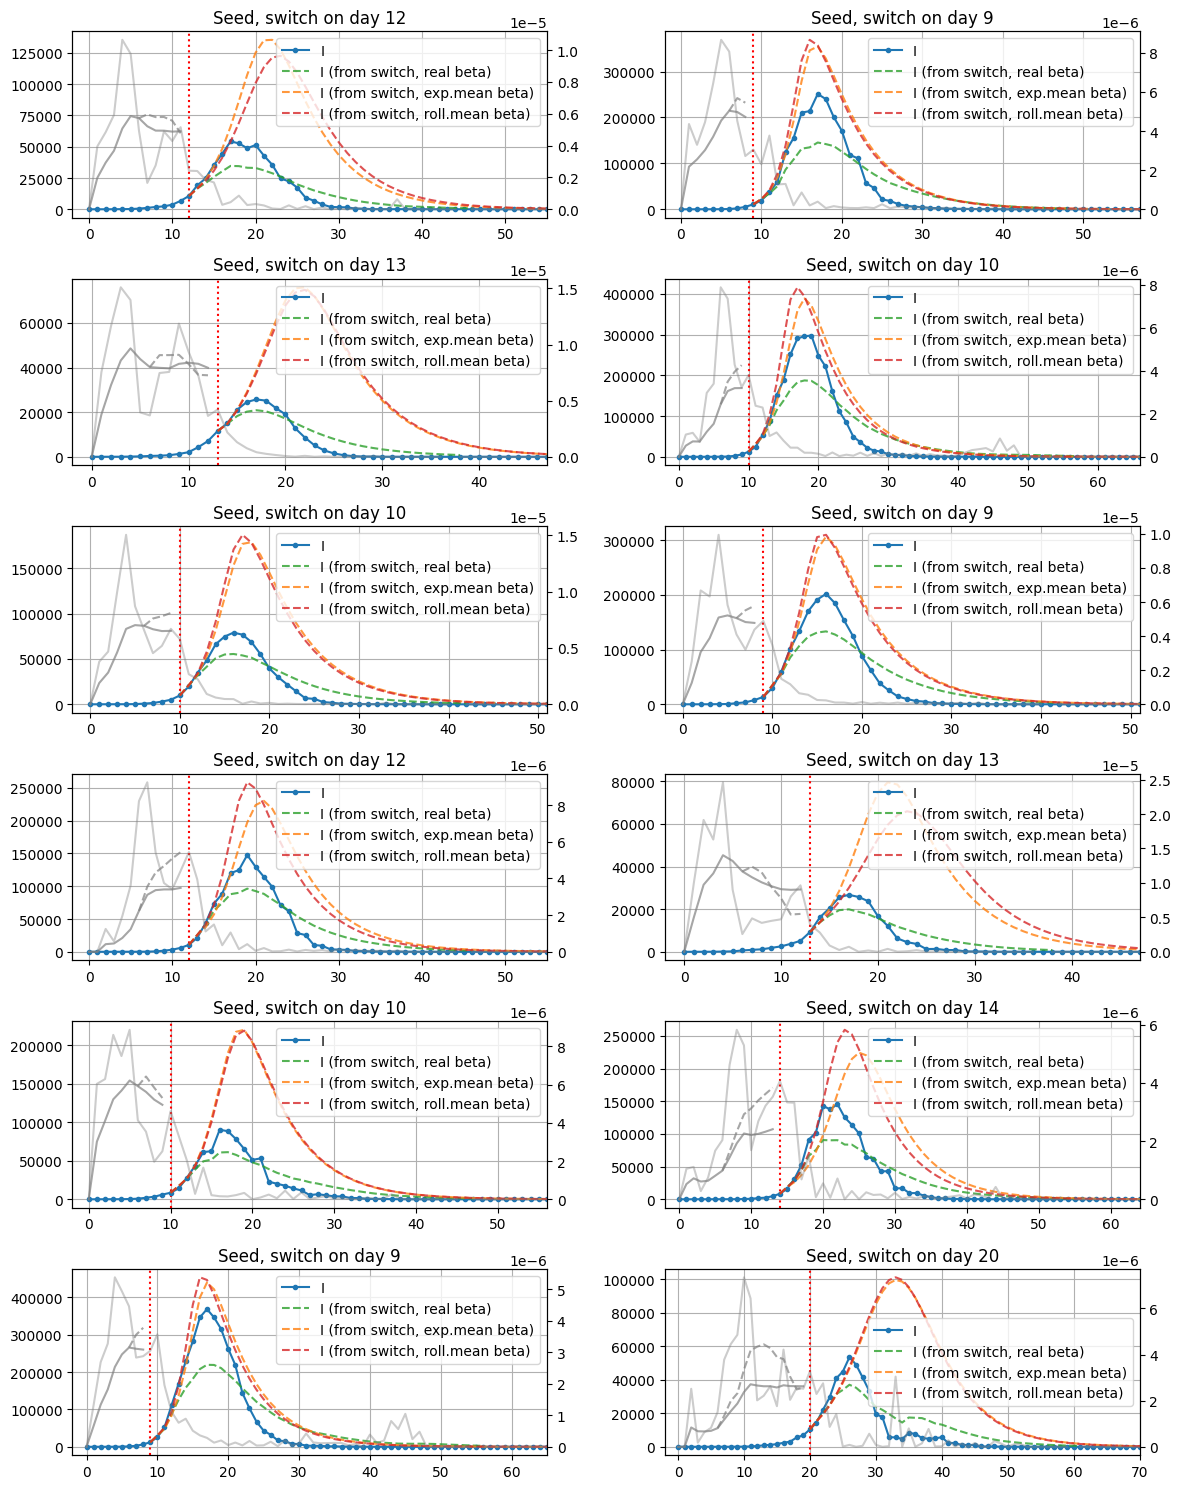

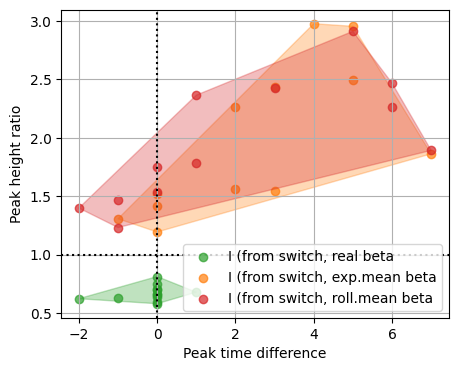

In [179]:
random.seed(42)

files =  [*X_train.values.flatten(), *X_val.values.flatten()]
files = np.array( random.sample(list(files), 12) )

r = switch.plot_hybrid_3(start_day='fraq_people', fraq=0.01,
                         sigma=1/2, gamma=1/6,
                         files=files)

0.02


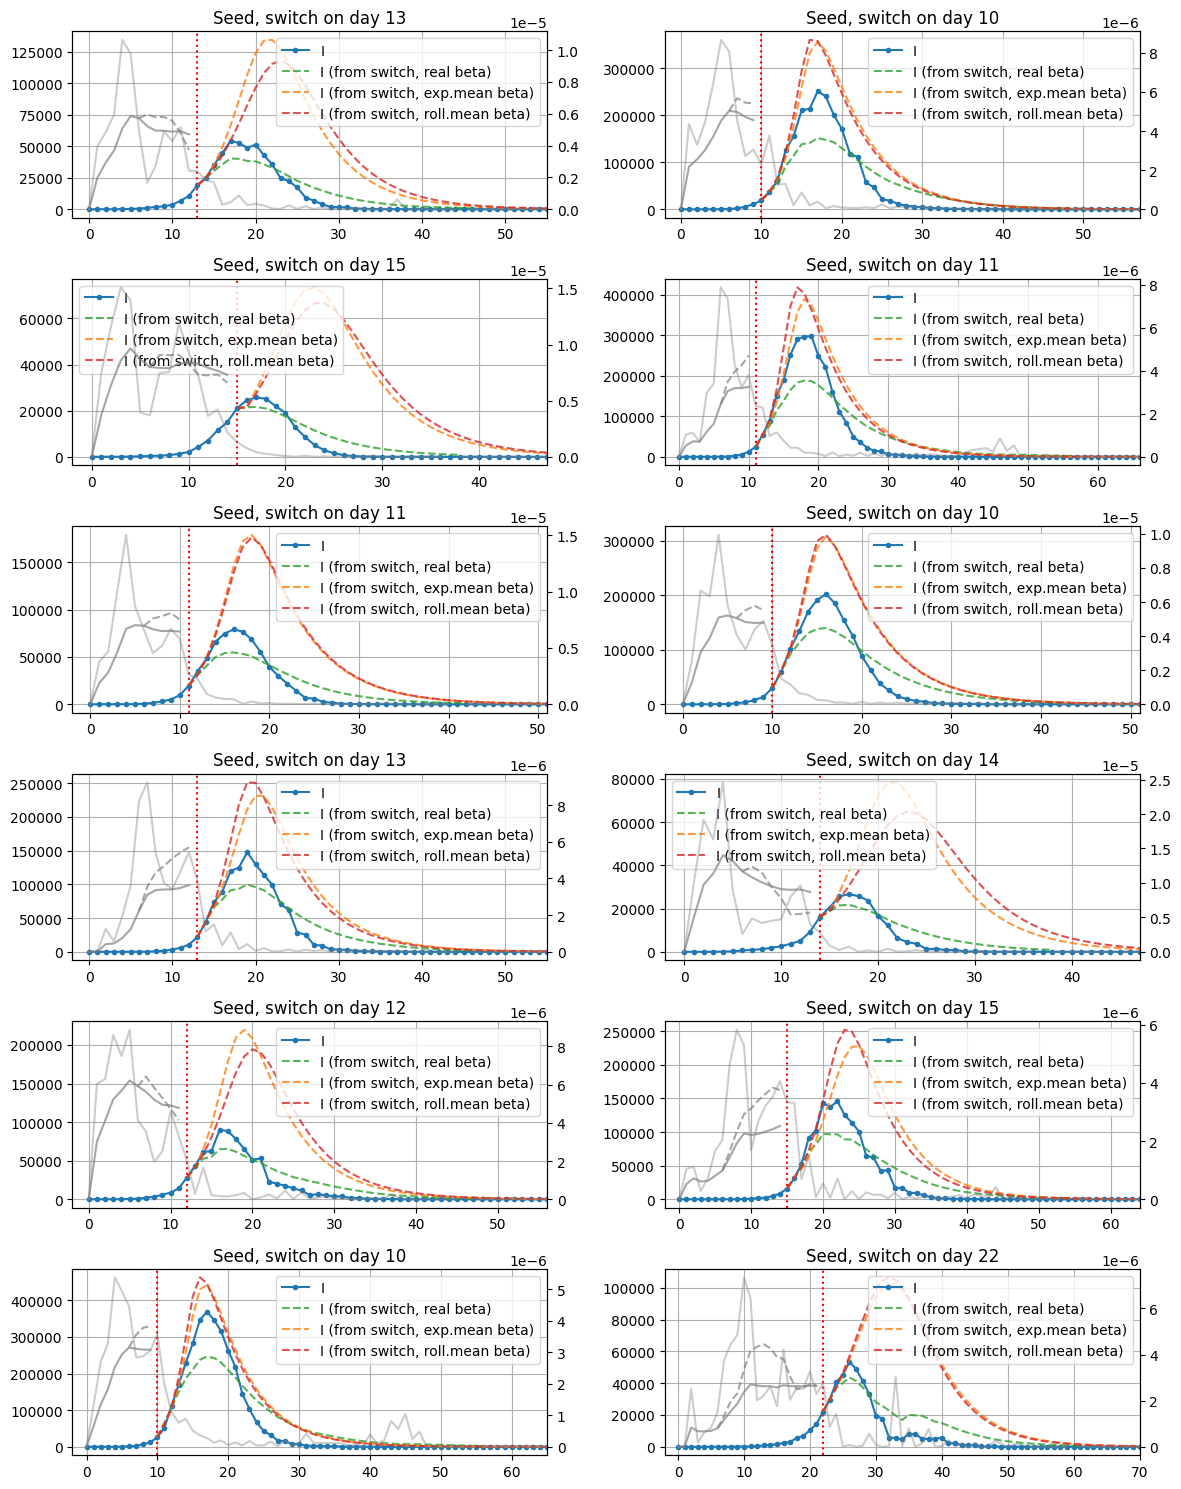

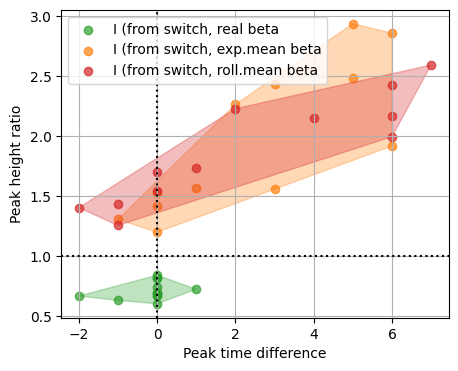

In [178]:
random.seed(42)

files =  [*X_train.values.flatten(), *X_val.values.flatten()]
files = np.array( random.sample(list(files), 12) )

r = switch.plot_hybrid_3(start_day='fraq_people', fraq=0.02,
                         sigma=1/2, gamma=1/6,
                         files=files)

In [181]:
np.array([*X_train.values.flatten(), *X_val.values.flatten()]).shape

(1303,)

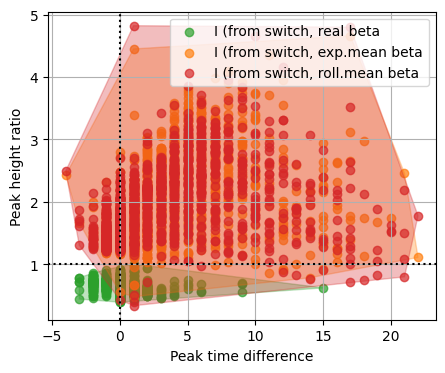

In [169]:
files =  np.array([*X_train.values.flatten(), *X_val.values.flatten()])

rr = switch.plot_hybrid_3(start_day='fraq_people', perc=0.01, 
                         sigma=1/2, gamma=1/6,
                         files=files, plot=False)

пучок бет становится Уже, если переключаемся ближе к пику

реальная бета дает лучшее приближение, если переключаемся на 0-м дне??

далее лучше приближает бета*коэфф.; причем чем дальше переключение, тем больше нужен коэфф.

### one beta, diff.days

In [12]:
one_seed = X_train_all['file'].values.flatten()[10]

Text(0.5, 0, 'Days')

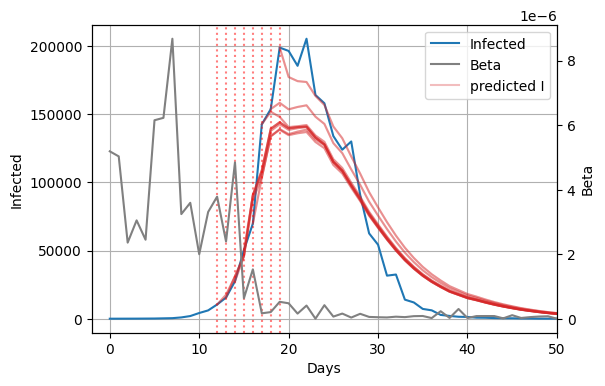

In [89]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')

for switch_day in range(12, 20):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()

    b = seed_df.Beta[switch_day:].values
    S,E,I,R = seir_discrete.seir_model(y0, ts, b, 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.3, label='predicted I')

lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)

 
ax.set_xlim(-2, 50)
ax.grid()    

ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

### diff. beta (coeff 0.5--1.5), one day

#### 10

Text(0.5, 0, 'Days')

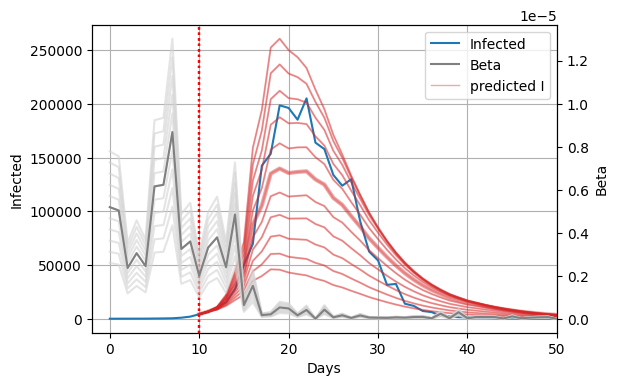

In [139]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 10

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 0

Text(0.5, 0, 'Days')

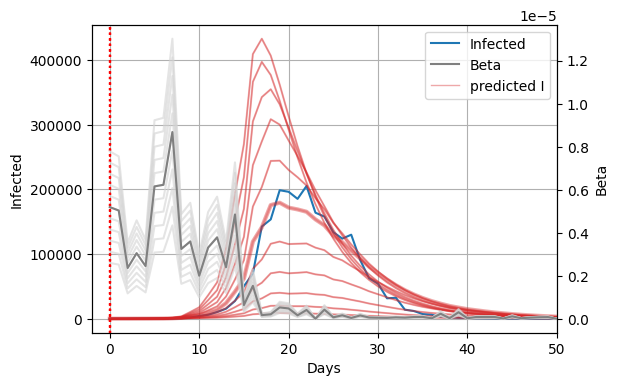

In [145]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day =0

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 5

In [153]:

for coeff in range(-5, 6):
    print((1 + coeff/10))

0.5
0.6
0.7
0.8
0.9
1.0
1.1
1.2
1.3
1.4
1.5


Text(0.5, 0, 'Days')

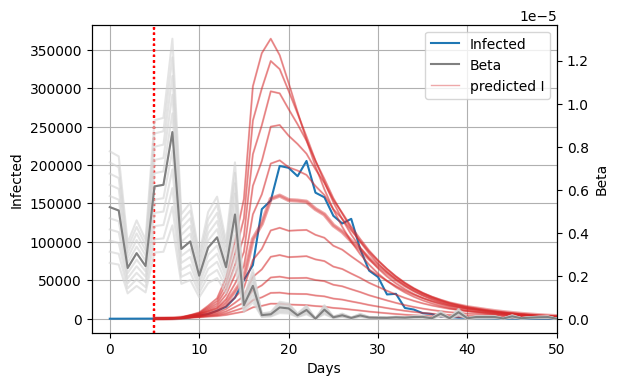

In [141]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 5

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 7

Text(0.5, 0, 'Days')

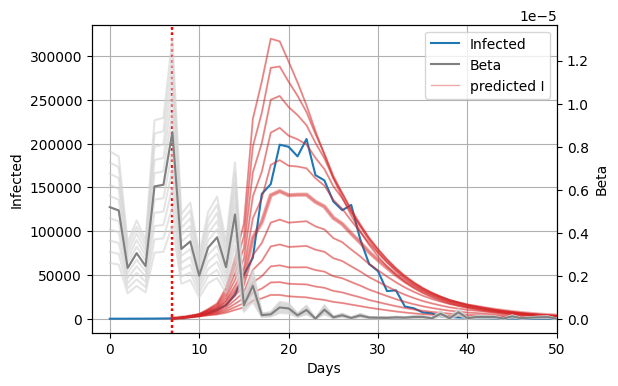

In [140]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 7

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 12

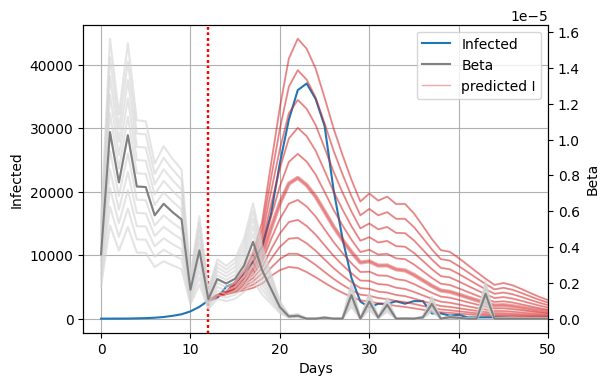

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 12

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

plt.savefig(f'results/coeffs_real_beta.pdf', 
            format='pdf', bbox_inches='tight')

Text(0.5, 0, 'Days')

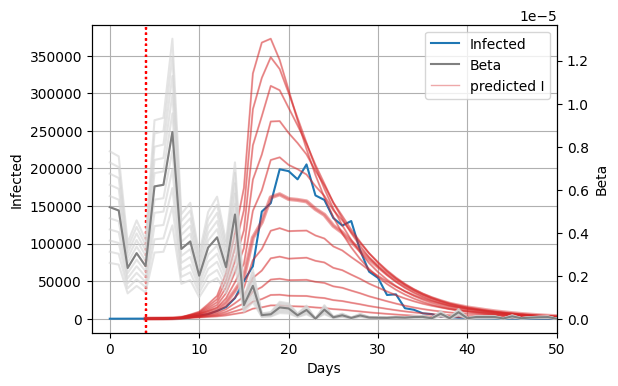

In [154]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 4

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

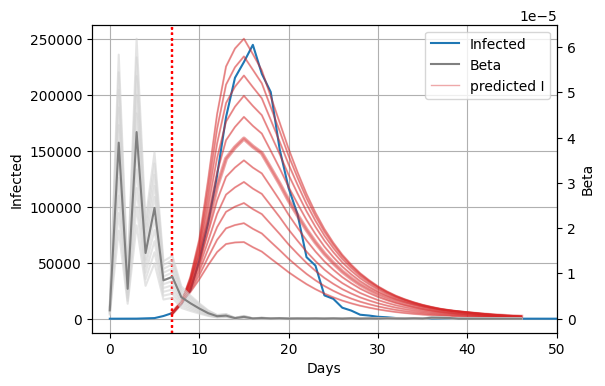

In [170]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[20]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 7

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

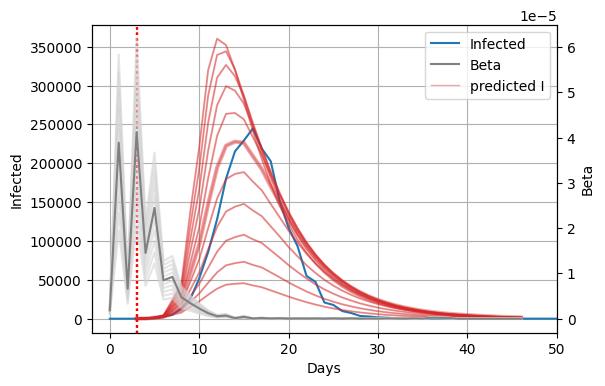

In [172]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[20]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 3

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

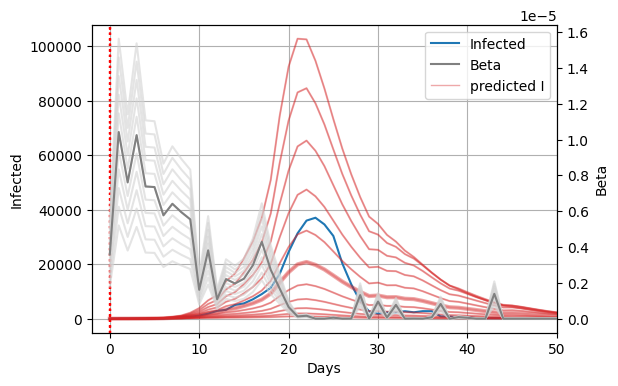

In [173]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 0

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

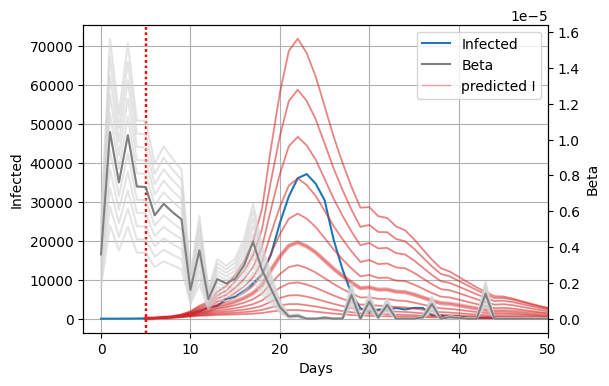

In [174]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 5

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

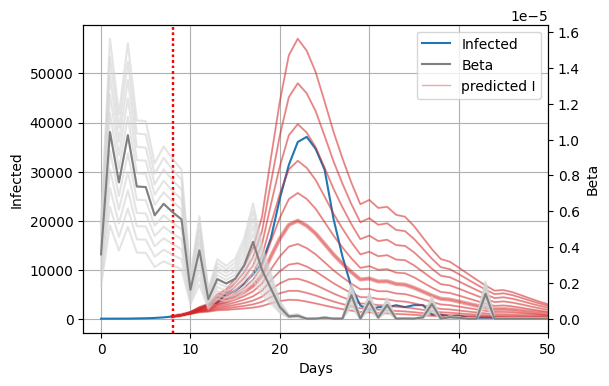

In [175]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 8

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

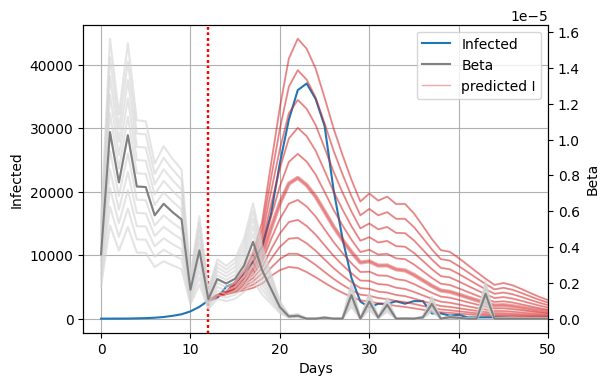

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 12

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

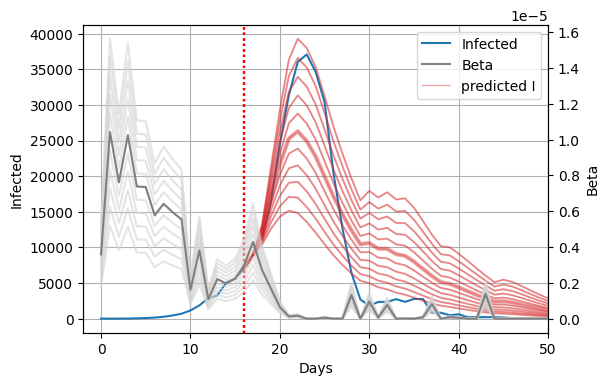

In [177]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 16

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

Text(0.5, 0, 'Days')

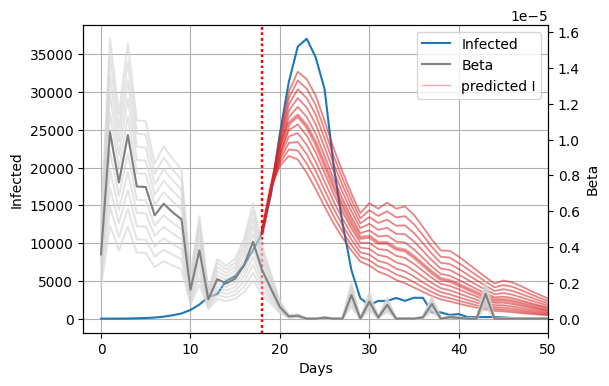

In [178]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

one_seed = X_train_all['file'].values.flatten()[30]
df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 18

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

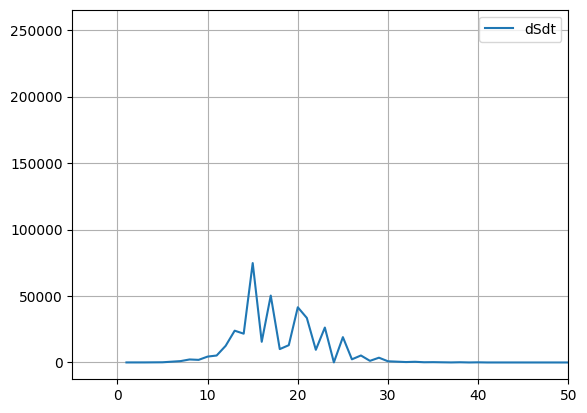

In [167]:
(-df.S_H1N1.diff()).plot(label='dSdt')
plt.xlim(-5,50)
plt.legend()
plt.grid()

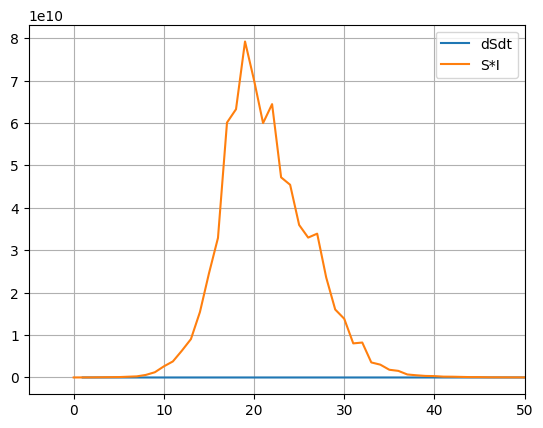

In [165]:
(-df.S_H1N1.diff()).plot(label='dSdt')
(df.S_H1N1*df.I_H1N1).plot(label='S*I')

plt.xlim(-5,50)
plt.legend()
plt.grid()

In [164]:
-df.S_H1N1.diff()

0        NaN
1       33.0
2       32.0
3       48.0
4      126.0
       ...  
245     -0.0
246     -0.0
247     -0.0
248     -0.0
249     -0.0
Name: S_H1N1, Length: 250, dtype: float64

#### 13

Text(0.5, 0, 'Days')

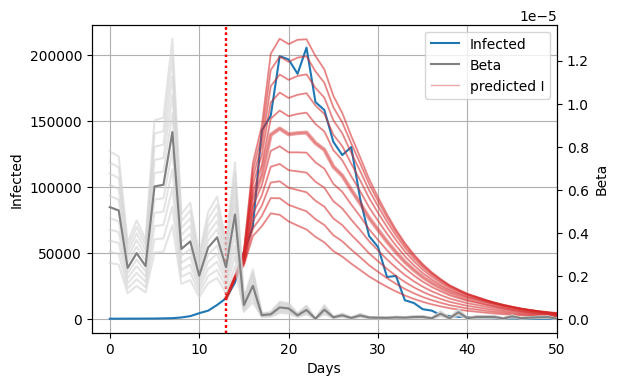

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 13

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 14

Text(0.5, 0, 'Days')

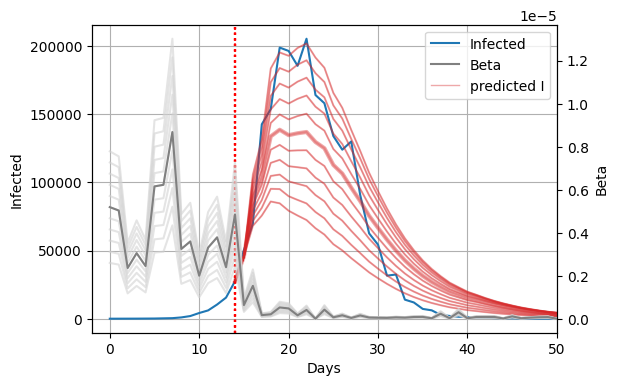

In [137]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 14

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 15

Text(0.5, 0, 'Days')

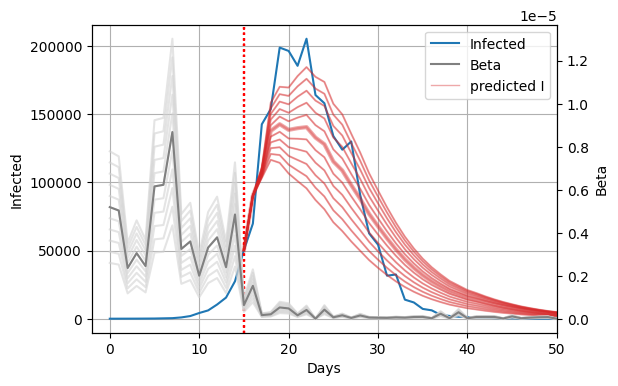

In [151]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 15

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 16

Text(0.5, 0, 'Days')

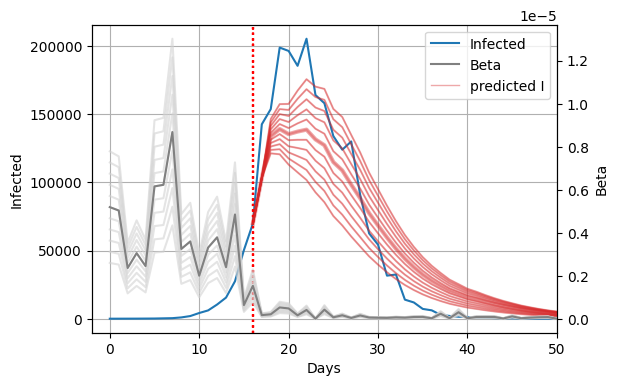

In [150]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 16

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

#### 17

Text(0.5, 0, 'Days')

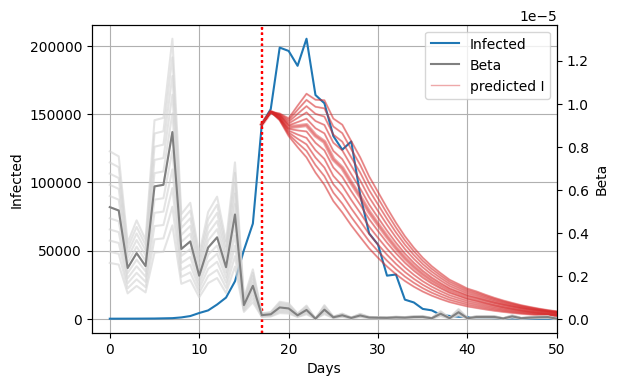

In [147]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 17

for coeff in range(-5, 6):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)
    if (1 + coeff/10) == 1:
        lw=3
    else:
        lw=1
        
    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)
 
ax.set_xlim(-2, 50)
ax.grid()    
ax.set_ylabel('Infected')
ax_b.set_ylabel('Beta')
ax.set_xlabel('Days')

### diff. beta (coeff 1.5--3), one day

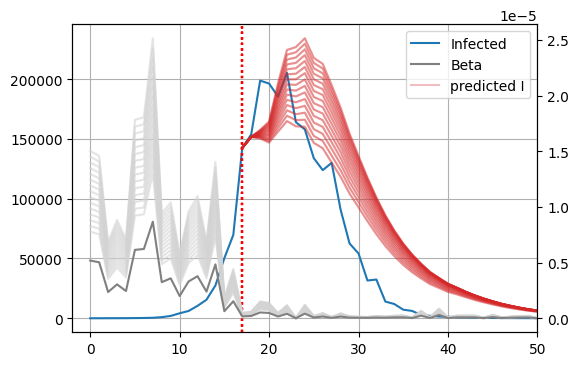

In [107]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 17

for coeff in range(5, 20):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()
    b = seed_df.Beta.values * (1 + coeff/10)
    ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
    S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.3, label='predicted I')
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)

 
ax.set_xlim(-2, 50)
ax.grid()    

### diff. beta (coeff 0.5--1.5), diff. days

In [118]:
import matplotlib as mpl

cmap = mpl.colormaps['viridis']
colors_l = cmap(np.linspace(0, 1, 8))

colors = list(colors_l)

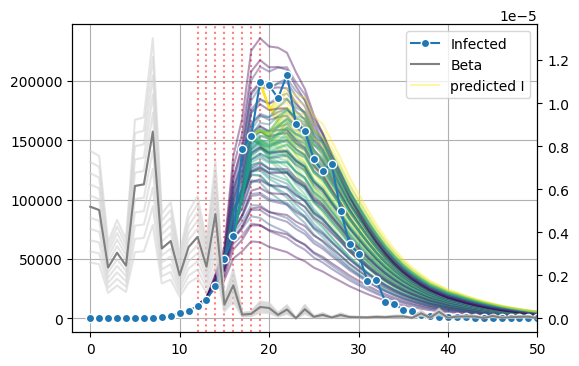

In [152]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)


seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 18

for i, coeff in enumerate(range(-5, 6)):
    
    for j, switch_day in enumerate(range(12,20)):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
        if i==0:
            ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   

        #switch_day=25
        y0 = seed_df.iloc[switch_day,:4].values
        ts = np.arange(seed_df.shape[0]-switch_day)

        sigma = 1/2
        gamma = 1/6

        res_dict = dict()
        b = seed_df.Beta.values * (1 + coeff/10)
        if j==0:
            ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
        
        S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                           sigma, gamma, stype='d', 
                                           beta_t=True).T
        
        predicted_peakt = I.argmax()+switch_day
        predicted_peakh = I.max()
        pt_err = abs(real_peakt - predicted_peakt)
        ph_err = abs(real_peakh - predicted_peakh)

        lw=1.5

        l3 = ax.plot(ts+switch_day, I, color=colors[j], ls='-', 
                        alpha=0.4, label='predicted I', lw=lw)
        
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected',
            marker='o', ls='-', markeredgecolor='white')    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')
lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)

 
ax.set_xlim(-2, 50)
ax.grid()    

### diff. beta (coeff 1.5--3), diff. days

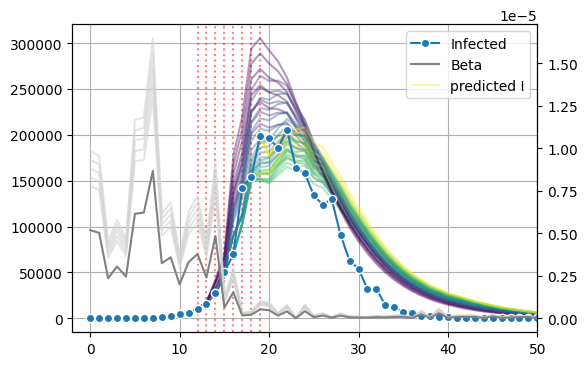

In [133]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)


seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()


switch_day = 18

for i, coeff in enumerate(range(5, 10)):
    
    for j, switch_day in enumerate(range(12,20)):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
        if i==0:
            ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   

        #switch_day=25
        y0 = seed_df.iloc[switch_day,:4].values
        ts = np.arange(seed_df.shape[0]-switch_day)

        sigma = 1/2
        gamma = 1/6

        res_dict = dict()
        b = seed_df.Beta.values * (1 + coeff/10)
        if j==0:
            ax_b.plot(b, color='lightgray', ls='-', alpha=0.6, label='Beta')
        
        S,E,I,R = seir_discrete.seir_model(y0, ts, b[switch_day:], 
                                           sigma, gamma, stype='d', 
                                           beta_t=True).T
        
        predicted_peakt = I.argmax()+switch_day
        predicted_peakh = I.max()
        pt_err = abs(real_peakt - predicted_peakt)
        ph_err = abs(real_peakh - predicted_peakh)

        lw=1.5

        l3 = ax.plot(ts+switch_day, I, color=colors[j], ls='-', 
                        alpha=0.4, label='predicted I', lw=lw)
    
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')

l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected',
            marker='o', ls='-', markeredgecolor='white')

lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)

 
ax.set_xlim(-2, 50)
ax.grid()    

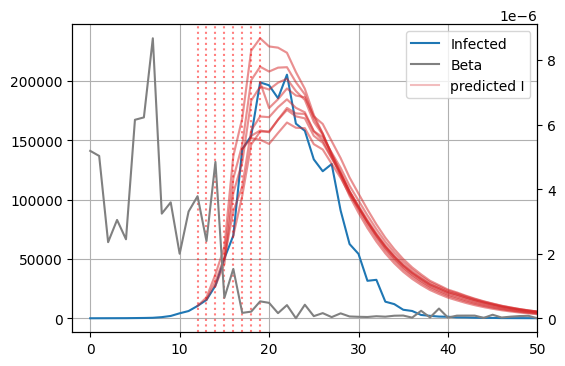

In [79]:
# если увеличить значение реальной беты в 1.5раз

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

df = pd.read_csv(one_seed)
l1 = ax.plot(df.I_H1N1, color='tab:blue', alpha=1, label='Infected')

seed_df = df.iloc[:,:5].copy()
seed_df.columns = ['S','E','I','R','Beta']
end_df  = seed_df[(seed_df.E==0)&(seed_df.I==0)]
if end_df.shape[0]:
    seed_df = seed_df.iloc[:end_df.index[0]].copy()

real_peakt = seed_df.I.argmax()
real_peakh = seed_df.I.max()
l2 = ax_b.plot(seed_df.Beta, color='gray', alpha=1, label='Beta')

for switch_day in range(12, 20):
#switch_day = choice_start_day.cpoint_fraq_people(seed_df, fraq=0.035)
    ax.axvline(switch_day, ls=':', color='red', alpha=0.5)   
    
    #switch_day=25
    y0 = seed_df.iloc[switch_day,:4].values
    ts = np.arange(seed_df.shape[0]-switch_day)

    sigma = 1/2
    gamma = 1/6

    res_dict = dict()

    b = seed_df.Beta[switch_day:].values * 1.5
    S,E,I,R = seir_discrete.seir_model(y0, ts, b, 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
            alpha=0.3)

    predicted_peakt = I.argmax()+switch_day
    predicted_peakh = I.max()
    pt_err = abs(real_peakt - predicted_peakt)
    ph_err = abs(real_peakh - predicted_peakh)

    l3 = ax.plot(ts+switch_day, I, color='tab:red', ls='-', 
                    alpha=0.3, label='predicted I')

lns = l1+l2+l3
labs = [l.get_label() for l in lns]

leg = ax.legend(lns, labs)

 
ax.set_xlim(-2, 50)
ax.grid()    

In [183]:
from sklearn.metrics import root_mean_squared_error as rmse

In [187]:
df_b[df_b.S_H1N1==0].index[0]

np.int64(52)

In [198]:

plot = True
df_b = pd.read_csv(one_seed)
fin = df_b[df_b.S_H1N1==0].index[0]
real_peakt = df_b.I_H1N1.argmax()
real_peakh = df_b.I_H1N1.max()

#st_day = choice_start_day.choose_method(df_b, start_day)
st_day = real_peakt - 7
betas = df_b.beta_H1N1

y0 = df_b.iloc[st_day,:4].values
ts = np.arange(fin-st_day)

col = 'tab:red'
lab = 'SEIR I (exp.mean beta)'

res_dict = dict()

for coeff in range(-5,6):
    b = betas[st_day:].values * (1 + coeff/10)
    #ax_beta.plot(b, ls='--', color='tab:green')
    r = seir_discrete.seir_model(y0, ts, b, 
                                       sigma, gamma, stype='d', 
                                       beta_t=True).T
    S,E,I,R = r
    if plot:
        ax.plot(ts+st_day, I, color=col, ls='-', alpha=0.3)
    predicted_peakt = I.argmax()+st_day
    predicted_peakh = I.max()

    rmse_pt = rmse([real_peakt], [predicted_peakt])
    rmse_ph = rmse([real_peakh], [predicted_peakh])
    res_dict[(1 + coeff/10)] = [rmse_pt,rmse_ph]

best_b = pd.DataFrame.from_dict(res_dict).T.reset_index()
best_b.columns = ['beta', 'rmse_pt', 'rmse_ph']


In [199]:
best_b

,beta,rmse_pt,rmse_ph
0,0.5,2.0,21911.649980
1,0.6,2.0,19977.642748
2,0.7,1.0,17863.528594
3,0.8,1.0,15568.085158
4,0.9,1.0,13205.294243
5,1.0,1.0,10778.322258
6,1.1,1.0,8290.395213
7,1.2,1.0,5744.793869
8,1.3,1.0,3144.848806
9,1.4,1.0,493.935427


In [192]:
rmse_pt, predicted_peakh

(2.0, np.float64(15165.350020065474))

### boxes

#### real, 4 days

(1, 1303)


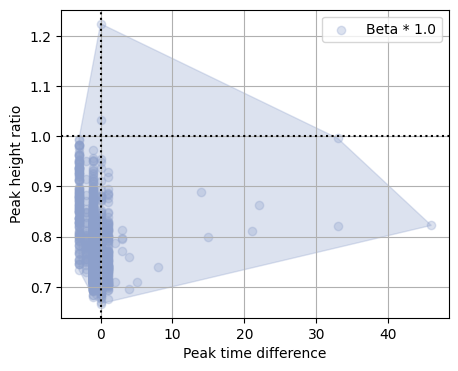

In [7]:
switch.beta_and_coeffs(start_day=3, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[0])

(1, 1303)


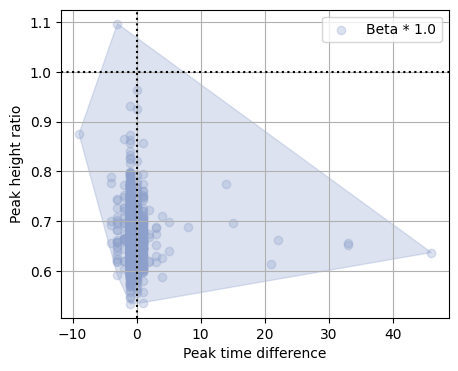

In [52]:
switch.beta_and_coeffs(start_day=10, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[0])

(1, 1303)


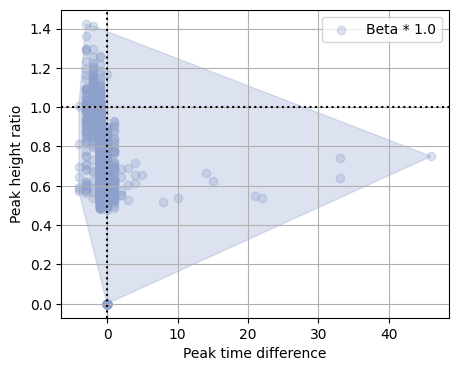

In [53]:
switch.beta_and_coeffs(start_day=15, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[0])

(1, 1303)


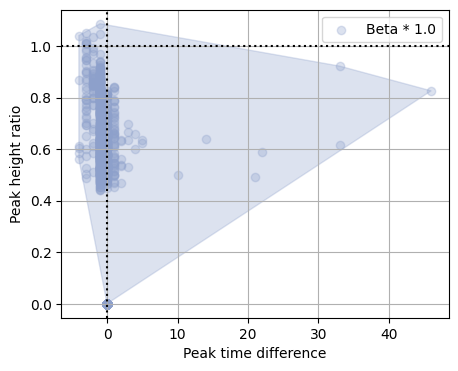

In [55]:
switch.beta_and_coeffs(start_day=18, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[0])

#### coeffs -2,0,2

(3, 1303)


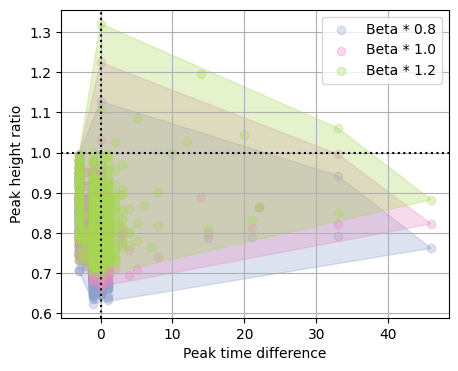

In [45]:
switch.beta_and_coeffs(start_day=3, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-2,0,2])

(3, 1303)


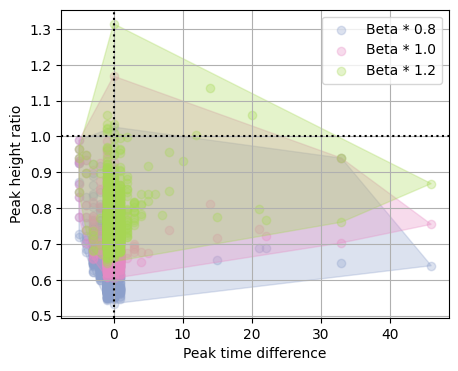

In [46]:
switch.beta_and_coeffs(start_day=5, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-2,0,2])

(3, 1303)


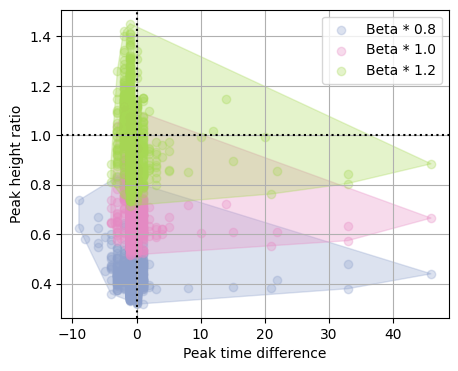

In [47]:
switch.beta_and_coeffs(start_day=12, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-2,0,2])

(3, 1303)


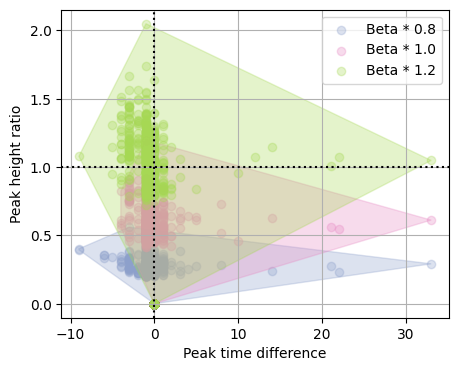

In [49]:
switch.beta_and_coeffs(start_day=20, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-2,0,2])

#### coeffs -4,-2,0,2,4

(5, 1303)


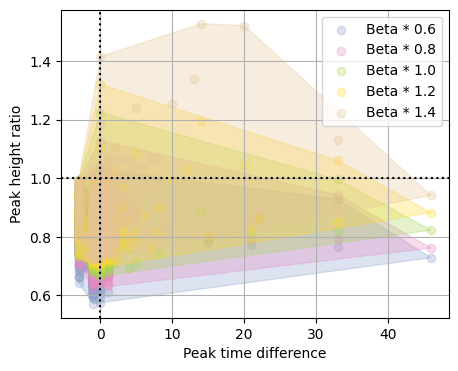

In [8]:
switch.beta_and_coeffs(start_day=3, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(5, 1303)


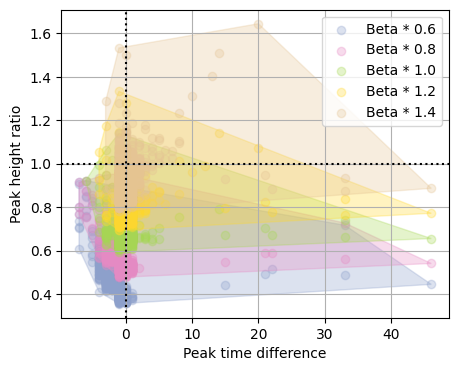

In [9]:
switch.beta_and_coeffs(start_day=7, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(5, 1303)


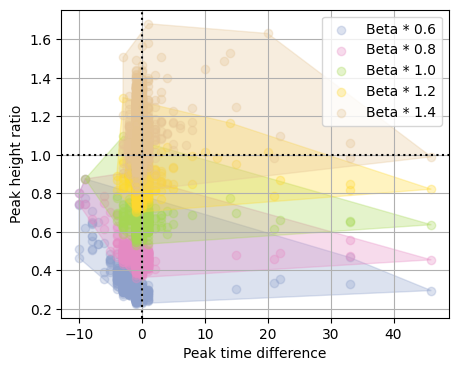

In [10]:
switch.beta_and_coeffs(start_day=10, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(5, 1303)


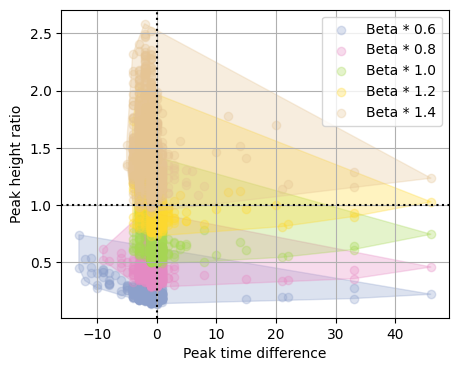

In [11]:
switch.beta_and_coeffs(start_day=14, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(5, 1303)


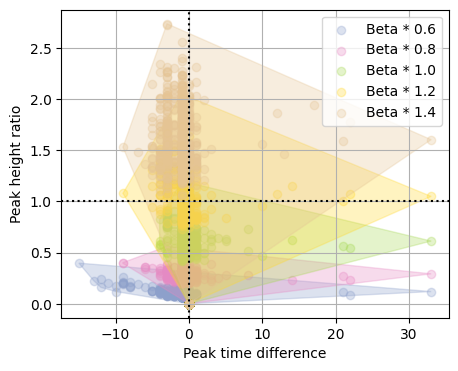

In [12]:
switch.beta_and_coeffs(start_day=20, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(5, 1303)


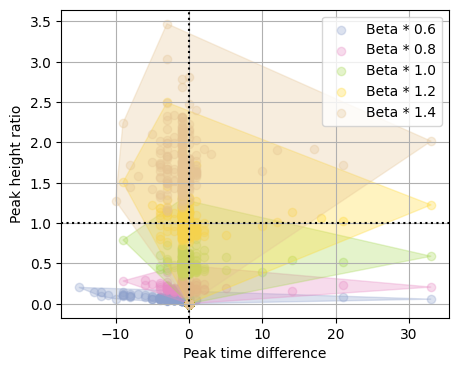

In [13]:
switch.beta_and_coeffs(start_day=25, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[-4,-2,0,2,4])

(2, 1303)


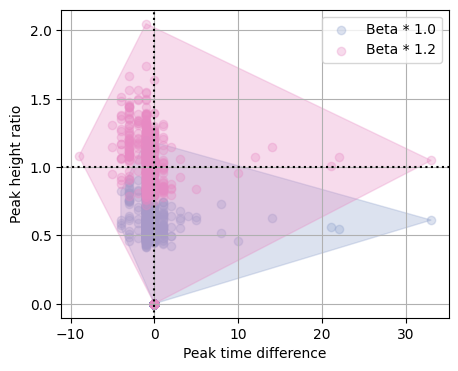

In [90]:
switch.beta_and_coeffs(start_day=20, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten(), 
                       plot=False, coeffs=[0,2])

(5, 4)


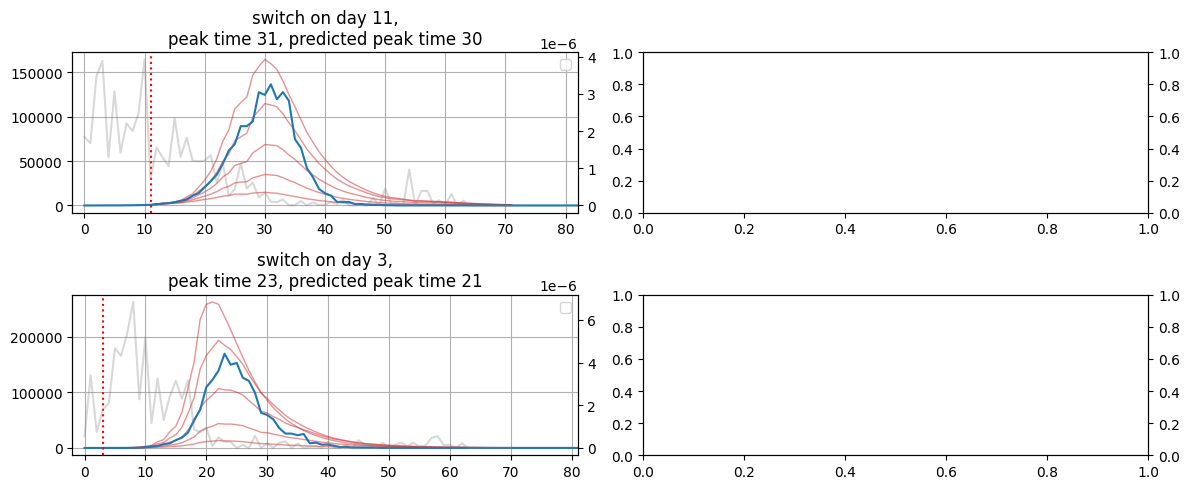

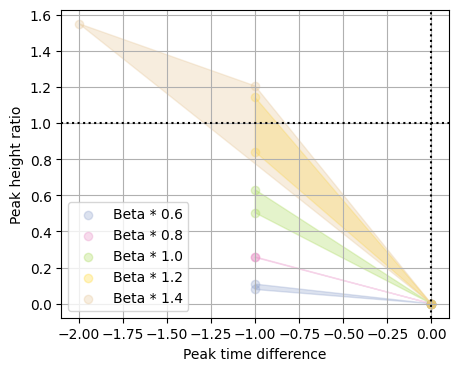

In [59]:
switch.beta_and_coeffs(start_day=20, sigma=1/2, gamma=1/6,
                      files = X_train_all['file'].values.flatten()[:4], 
                       plot=True, coeffs=[-4,-2,0,2,4])

#### days (20,15,10,5)

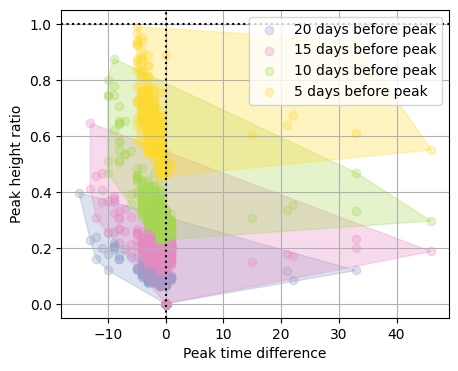

In [14]:
switch.beta_and_coeffs_days(start_days=[20,15,10,5], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = -4)

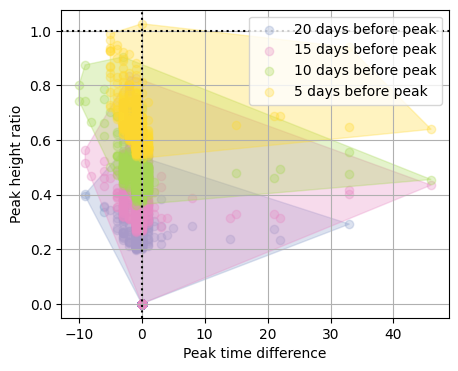

In [15]:
switch.beta_and_coeffs_days(start_days=[20,15,10,5], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = -2)

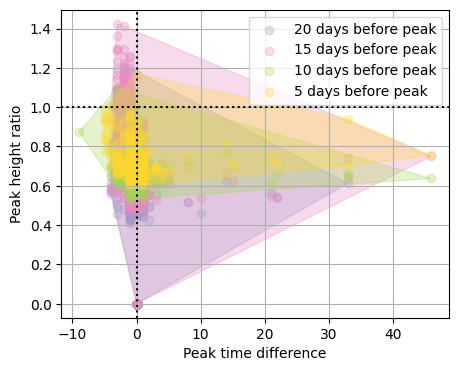

In [16]:
switch.beta_and_coeffs_days(start_days=[20,15,10,5], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = 0)

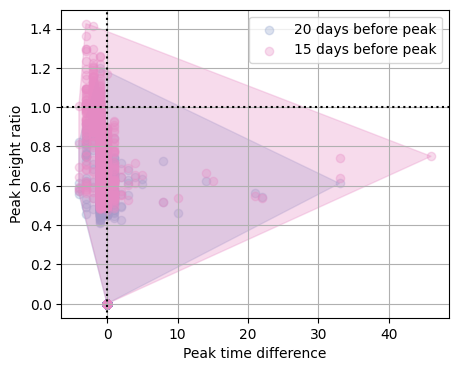

In [79]:
switch.beta_and_coeffs_days(start_days=[20,15], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = 0)

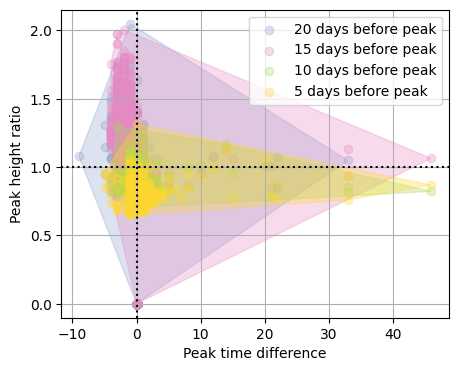

In [17]:
switch.beta_and_coeffs_days(start_days=[20,15,10,5], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = 2)

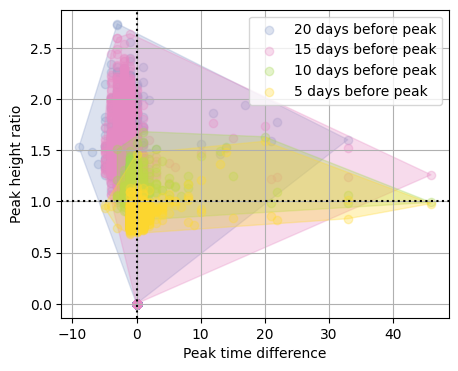

In [18]:
switch.beta_and_coeffs_days(start_days=[20,15,10,5], sigma=1/2, gamma=1/6,
                              files = X_train_all['file'].values.flatten(),
                            plot=False, coeff = 4)

In [237]:
df_b = pd.read_csv(X_train_all['file'].values.flatten()[80])
df_b

,S_H1N1,E_H1N1,I_H1N1,R_H1N1,beta_H1N1
0,318117.0,7.0,10.0,477202.0,-0.000000e+00
1,318117.0,7.0,10.0,477202.0,1.571749e-06
2,318112.0,5.0,17.0,477202.0,3.698291e-07
3,318110.0,7.0,17.0,477202.0,-0.000000e+00
4,318110.0,2.0,22.0,477202.0,1.428894e-07
...,...,...,...,...,...
245,0.0,0.0,0.0,0.0,NaN
246,0.0,0.0,0.0,0.0,NaN
247,0.0,0.0,0.0,0.0,NaN
248,0.0,0.0,0.0,0.0,NaN


<Axes: >

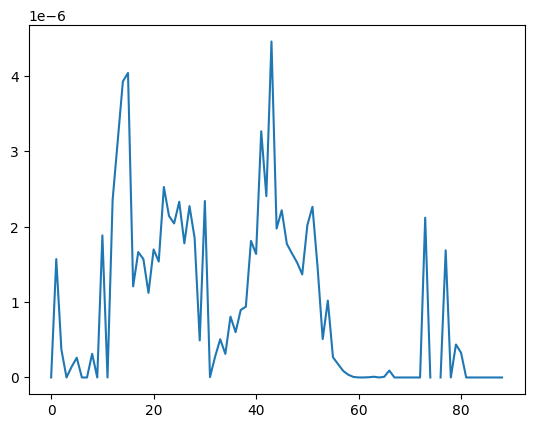

In [240]:
df_b.iloc[:89].beta_H1N1.plot()

<Axes: >

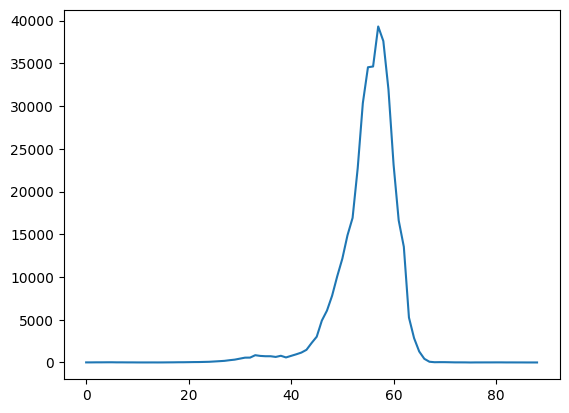

In [241]:
df_b.iloc[:89].I_H1N1.plot()

In [238]:
fin = df_b[df_b.S_H1N1==0].index[0]
fin

np.int64(89)

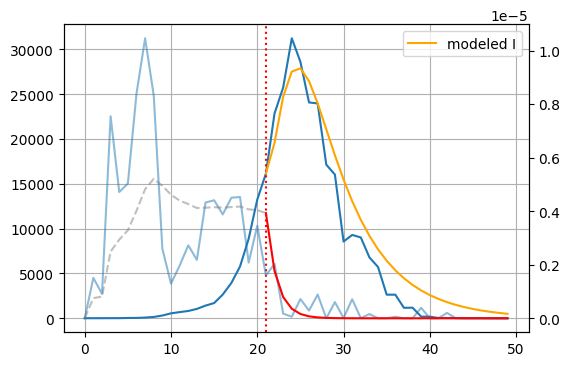

In [250]:
# from b0 to phi*b0 at rate q. phi ~ 1/r_0
def func(t, b0, phi, q):
    return b0*( (1-phi)*np.exp(-q*t) + phi)

switch_day = seed_df.I.argmax()-3

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

ax.plot(seed_df.I)
ax_b.plot(seed_df.Beta, alpha=0.5)
beta_e = seed_df.Beta.expanding().mean()[:switch_day+1]
ax_b.plot(beta_e, alpha=0.5, ls='--', color='gray')

days = np.arange(switch_day, seed_df.shape[0])
b0 = beta_e.iloc[-1]
phi = (1/2)*b0
q = 0.8

ax.axvline(switch_day, ls=':', color='red')


y0 = df.iloc[switch_day,:4].values
bb = func(days-switch_day , b0, phi, q)

ax_b.plot(days, bb, color='red')

S,E,I,R = seir_discrete.seir_model(y0, days-switch_day, bb,
                                   sigma, gamma, stype='d', 
                                   beta_t=True).T
ax.plot(days, I, color='orange', ls='-', 
        alpha=1, label='modeled I')

ax.grid()
ax.legend()

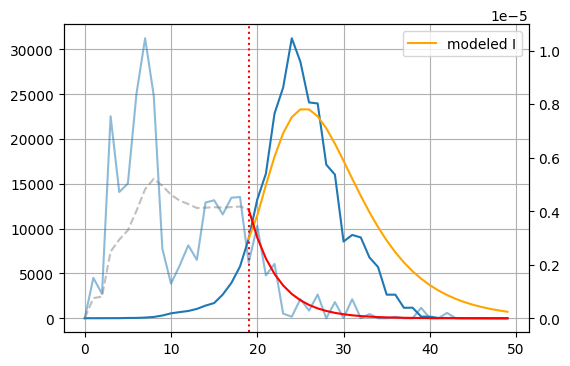

In [246]:
# from b0 to phi*b0 at rate q. phi ~ 1/r_0
def func(t, b0, phi, q):
    return b0*( (1-phi)*np.exp(-q*t) + phi)

switch_day = seed_df.I.argmax()-5

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax_b = ax.twinx()

ax.plot(seed_df.I)
ax_b.plot(seed_df.Beta, alpha=0.5)
beta_e = seed_df.Beta.expanding().mean()[:switch_day+1]
ax_b.plot(beta_e, alpha=0.5, ls='--', color='gray')

days = np.arange(switch_day, seed_df.shape[0])
b0 = beta_e.iloc[-1]
phi = (1/2)*b0
q = 0.3

ax.axvline(switch_day, ls=':', color='red')


y0 = df.iloc[switch_day,:4].values
bb = func(days-switch_day , b0, phi, q)

ax_b.plot(days, bb, color='red')

S,E,I,R = seir_discrete.seir_model(y0, days-switch_day, bb,
                                   sigma, gamma, stype='d', 
                                   beta_t=True).T
ax.plot(days, I, color='orange', ls='-', 
        alpha=1, label='modeled I')

ax.grid()
ax.legend()